<a href="https://colab.research.google.com/github/iagooleite/Calculo-Numerico/blob/main/Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade I Cálculo numérico - Erros numéricos em aplicações simples de biofluidodinâmica**

Iago da Silva Leite | RA: 185228

---



## **Parte A - Truncamento e Arredondamento**

Tabela de Resultados:

         x  n  Truncado  Ea (Trunc)  Er (Trunc)  E% (Trunc)  Arredondado   Ea (Arr)    Er (Arr)    E% (Arr)
   3.14159  0         3    0.141593   0.0450703     4.50703            3   0.141593   0.0450703     4.50703
   3.14159  1       3.1   0.0415927   0.0132394     1.32394          3.1  0.0415927   0.0132394     1.32394
   3.14159  2      3.14  0.00159265 0.000506956   0.0506956         3.14 0.00159265 0.000506956   0.0506956
   3.14159  3     3.141  0.00059265 0.000188646   0.0188646        3.142 0.00040735 0.000129664   0.0129664
   3.14159  4    3.1415   9.265e-05 2.94914e-05  0.00294914       3.1416   7.35e-06 2.33958e-06 0.000233958
   98.7654  0        98     0.76543  0.00774998    0.774998           99    0.23457  0.00237502    0.237502
   98.7654  1      98.7     0.06543 0.000662479   0.0662479         98.8    0.03457 0.000350021   0.0350021
   98.7654  2     98.76     0.00543 5.49788e-05  0.00549788        98.77    0.00457 4.62713e-05  0.00462713
   98

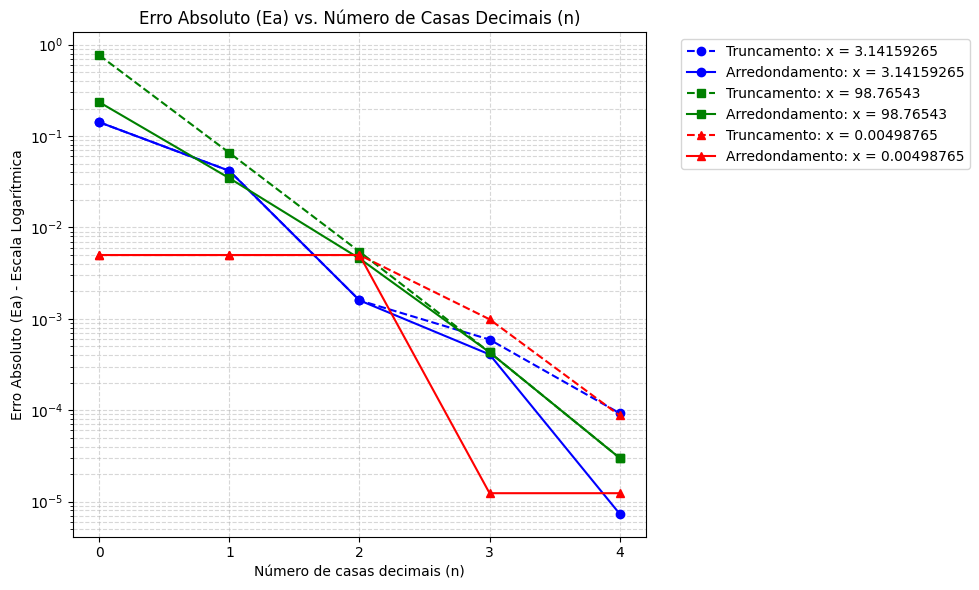

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# Valores fornecidos
x_valores = [3.14159265, 98.76543, 0.00498765]
n_valores = [0, 1, 2, 3, 4]

# Lista para armazenar os resultados
resultados = []

# Função auxiliar para truncamento
def truncar(valor, n):
    fator = 10.0 ** n
    return math.trunc(valor * fator) / fator

# Cálculo das aproximações e dos erros
for x in x_valores:
    for n in n_valores:
        # Truncamento
        x_trunc = truncar(x, n)
        ea_trunc = abs(x - x_trunc)              # Erro Absoluto
        er_trunc = ea_trunc / abs(x)             # Erro Relativo
        ep_trunc = er_trunc * 100                # Erro Percentual

        # Arredondamento
        x_round = round(x, n)
        ea_round = abs(x - x_round)
        er_round = ea_round / abs(x)
        ep_round = er_round * 100

        # Guardando os dados
        resultados.append({
            'x': x,
            'n': n,
            'Truncado': x_trunc,
            'Ea (Trunc)': ea_trunc,
            'Er (Trunc)': er_trunc,
            'E% (Trunc)': ep_trunc,
            'Arredondado': x_round,
            'Ea (Arr)': ea_round,
            'Er (Arr)': er_round,
            'E% (Arr)': ep_round
        })

# Organizando os resultados em uma tabela
df = pd.DataFrame(resultados)

# Exibindo a tabela formatada
print("Tabela de Resultados:\n")
print(df.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

# Gráfico em escala logarítmica de Ea em função de n
plt.figure(figsize=(10, 6))

cores = ['blue', 'green', 'red']
marcadores = ['o', 's', '^']

for i, x in enumerate(x_valores):
    df_x = df[df['x'] == x]

    # Plotando o erro de Truncamento (linha tracejada)
    plt.plot(df_x['n'], df_x['Ea (Trunc)'], marker=marcadores[i], linestyle='--',
             color=cores[i], label=f'Truncamento: x = {x}')

    # Plotando o erro de Arredondamento (linha contínua)
    plt.plot(df_x['n'], df_x['Ea (Arr)'], marker=marcadores[i], linestyle='-',
             color=cores[i], label=f'Arredondamento: x = {x}')

# Configurações do gráfico
plt.yscale('log') # Escala Logarítmica no eixo Y
plt.xlabel('Número de casas decimais (n)') # Número n de casas decimais no eixo X
plt.ylabel('Erro Absoluto (Ea) - Escala Logarítmica')
plt.title('Erro Absoluto (Ea) vs. Número de Casas Decimais (n)')
plt.xticks(n_valores)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar o gráfico
plt.show()

## **Parte B – medidas de pressão arterial**


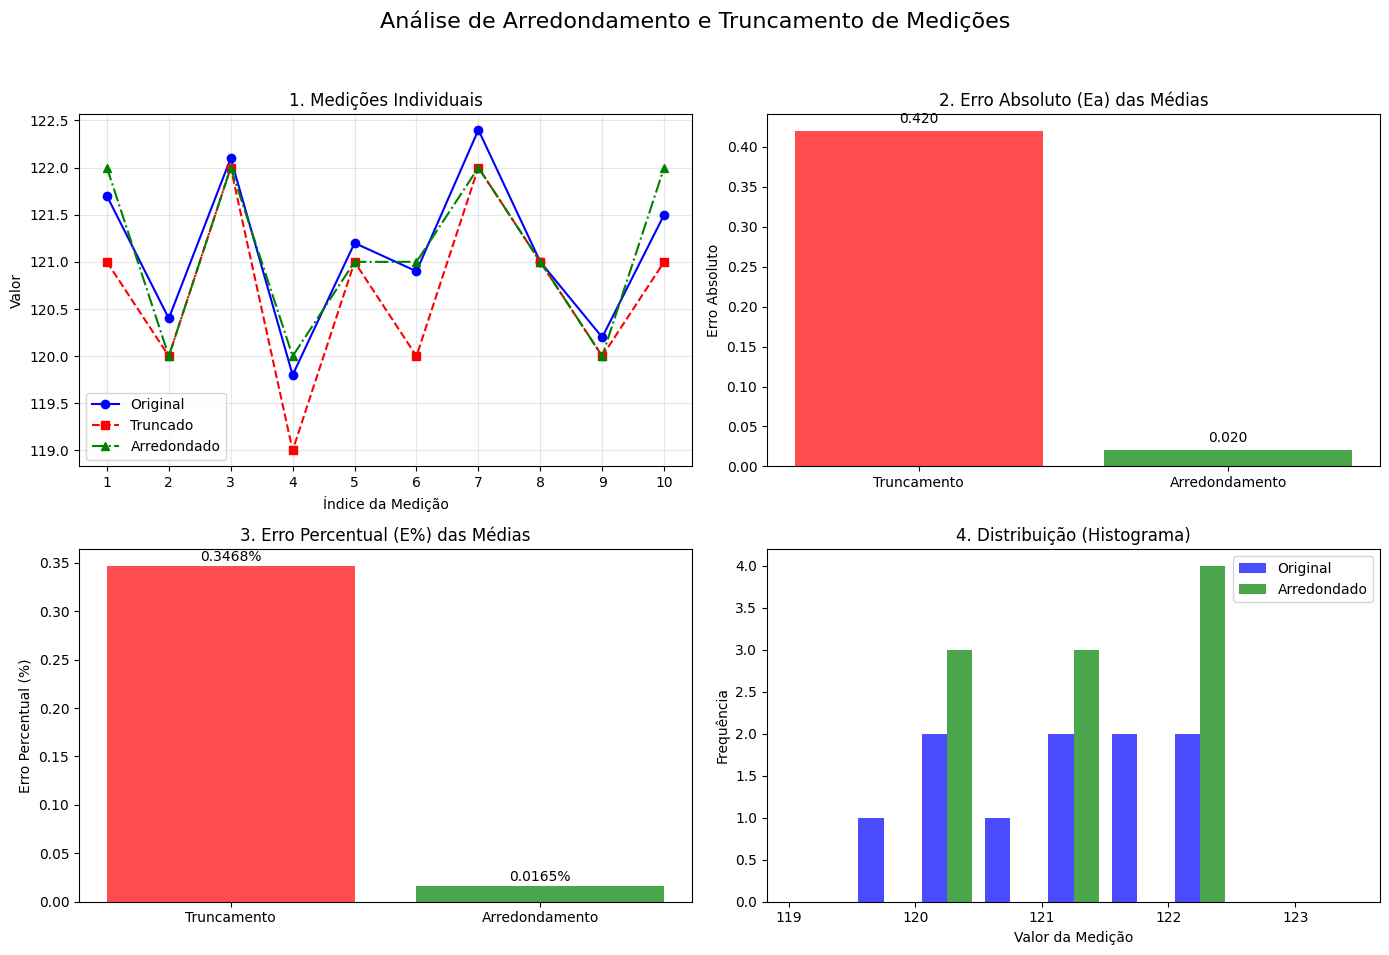

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import numpy as np

# Medidas fornecidas
medidas = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

# Medidas truncadas
medidas_trunc = []

# Medida arredondada
medidas_arr = []

# Trunca todas as medidas
medidas_trunc = [math.trunc(m) for m in medidas]

# Arredonda todas as medidas
medidas_arr = [round(m) for m in medidas]

def calculos_estatisticos(dado):
    minimo = min(dado)
    maximo = max(dado)
    amplitude = maximo - minimo
    media = statistics.mean(dado)          # Alterado de 'dados' para 'dado'
    desvio_padrao = statistics.stdev(dado) # Alterado de 'dados' para 'dado'

    # Retorna os resultados organizados em um dicionário
    return {
        "Mínimo": minimo,
        "Máximo": maximo,
        "Amplitude": amplitude,
        "Média": media,
        "Desvio Padrão": desvio_padrao
    }

# Aplicando a função para todas as listas e armazenando os resultados
resultados_originais = calculos_estatisticos(medidas)
resultados_truncados = calculos_estatisticos(medidas_trunc)
resultados_arredondados = calculos_estatisticos(medidas_arr)

def calcular_erros(media_ref, media_aprox):
    # Erro Absoluto (Ea)
    ea = abs(media_ref - media_aprox)

    # Erro Relativo (Er)
    er = ea / abs(media_ref)

    # Erro Percentual (E%)
    ep = er * 100

    # Retornando os resultados organizados
    return {
        "Erro Absoluto (Ea)": ea,
        "Erro Relativo (Er)": er,
        "Erro Percentual (E%)": ep
    }

# Pegamos as médias que calculamos antes
media_original = resultados_originais["Média"]
media_truncada = resultados_truncados["Média"]
media_arredondada = resultados_arredondados["Média"]

# Calculamos os erros
erros_truncamento = calcular_erros(media_original, media_truncada)
erros_arredondamento = calcular_erros(media_original, media_arredondada)

# Extraindo os erros dos dicionários para facilitar a plotagem
ea_trunc = erros_truncamento["Erro Absoluto (Ea)"]
ea_arr = erros_arredondamento["Erro Absoluto (Ea)"]

ep_trunc = erros_truncamento["Erro Percentual (E%)"]
ep_arr = erros_arredondamento["Erro Percentual (E%)"]

# Configuração do Painel de Gráficos (2 linhas, 2 colunas)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Arredondamento e Truncamento de Medições', fontsize=16)

# Gráfico 1: As 10 medições
x = np.arange(1, 11)
axs[0, 0].plot(x, medidas, marker='o', label='Original', color='blue')
axs[0, 0].plot(x, medidas_trunc, marker='s', linestyle='--', label='Truncado', color='red')
axs[0, 0].plot(x, medidas_arr, marker='^', linestyle='-.', label='Arredondado', color='green')

axs[0, 0].set_title('1. Medições Individuais')
axs[0, 0].set_xlabel('Índice da Medição')
axs[0, 0].set_ylabel('Valor')
axs[0, 0].set_xticks(x)
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Erros Absolutos das Médias
categorias = ['Truncamento', 'Arredondamento']
erros_abs = [ea_trunc, ea_arr]
cores = ['red', 'green']

axs[0, 1].bar(categorias, erros_abs, color=cores, alpha=0.7)
axs[0, 1].set_title('2. Erro Absoluto (Ea) das Médias')
axs[0, 1].set_ylabel('Erro Absoluto')
for i, v in enumerate(erros_abs):
    axs[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Gráfico 3: Erros Percentuais das Médias
erros_perc = [ep_trunc, ep_arr]

axs[1, 0].bar(categorias, erros_perc, color=cores, alpha=0.7)
axs[1, 0].set_title('3. Erro Percentual (E%) das Médias')
axs[1, 0].set_ylabel('Erro Percentual (%)')
for i, v in enumerate(erros_perc):
    axs[1, 0].text(i, v + 0.005, f'{v:.4f}%', ha='center')

# Gráfico 4: Histograma (Original vs Arredondado)
bins = np.arange(119, 124, 0.5)
axs[1, 1].hist([medidas, medidas_arr], bins=bins, label=['Original', 'Arredondado'], color=['blue', 'green'], alpha=0.7)
axs[1, 1].set_title('4. Distribuição (Histograma)')
axs[1, 1].set_xlabel('Valor da Medição')
axs[1, 1].set_ylabel('Frequência')
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **Parte C – vazão em um tubo de pequeno diâmetro**

--- Resultados Parte C.1 ---
           Cenário      Q (Arr)  E% (Arr)    Q (Trunc)  E% (Trunc)
        Referência 2.757421e-07       0.0 2.757421e-07    0.000000
        r (1 casa) 2.757421e-07       0.0 2.757421e-07    0.000000
      mu (3 casas) 2.412743e-07      12.5 3.216991e-07   16.666667
     dp (centenas) 2.757421e-07       0.0 2.757421e-07    0.000000
Todas simulatâneas 2.412743e-07      12.5 3.216991e-07   16.666667


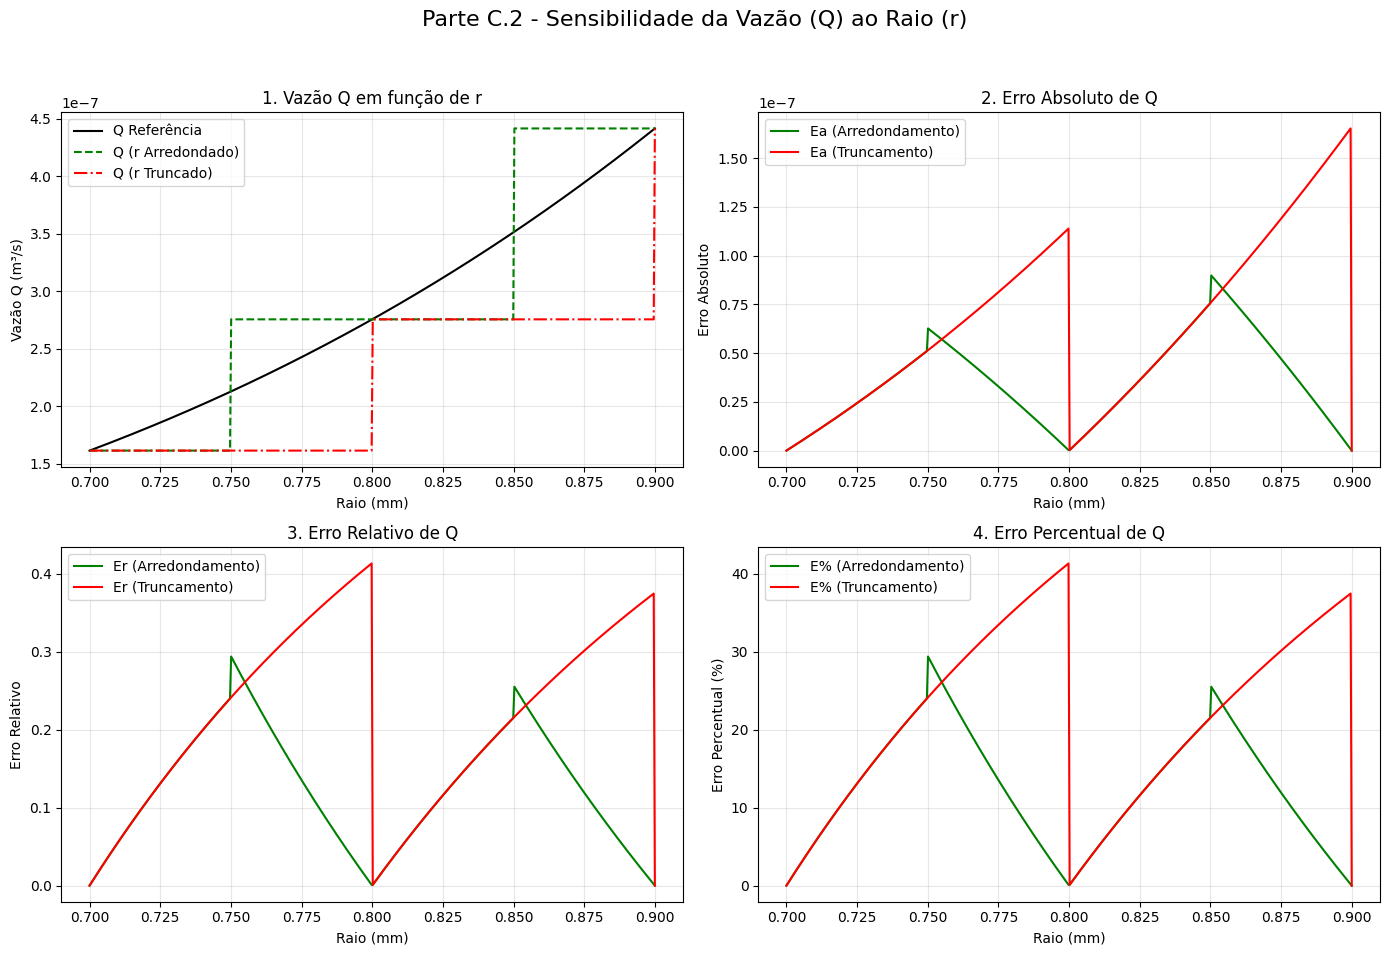

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Função de truncamento
def truncar(x, n):
    fator = 10.0 ** n
    return math.trunc(x * fator) / fator

def calcular_erros(ref, aprox):
    ea = abs(ref - aprox)
    er = ea / abs(ref) if ref != 0 else 0
    ep = er * 100
    return ea, er, ep

# Fórmula de Hagen-Poiseuille
def vazao_Q(r_m, mu, dp, L):
    return (math.pi * (r_m**4) * dp) / (8 * mu * L)

# Valores de referência
L = 0.20           # m
r_mm_ref = 0.80    # mm
mu_ref = 0.0035    # Pa.s (3.5 x 10^-3)
dp_ref = 1200.0    # Pa

# Q usando todos os valores fornecidos
Q_ref = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_ref, L)

# r arredondado e truncado para 1 casa decimal em mm
r_mm_arr = round(r_mm_ref, 1)
r_mm_trunc = truncar(r_mm_ref, 1)
Q_r_arr = vazao_Q(r_mm_arr * 1e-3, mu_ref, dp_ref, L)
Q_r_trunc = vazao_Q(r_mm_trunc * 1e-3, mu_ref, dp_ref, L)

# mu arredondada e truncada para 3 casas decimais em Pa.s
mu_arr = round(mu_ref, 3)
mu_trunc = truncar(mu_ref, 3)
Q_mu_arr = vazao_Q(r_mm_ref * 1e-3, mu_arr, dp_ref, L)
Q_mu_trunc = vazao_Q(r_mm_ref * 1e-3, mu_trunc, dp_ref, L)

# dp arredondada e truncada para centenas de pascal (n = -2)
dp_arr = round(dp_ref, -2)
dp_trunc = truncar(dp_ref, -2)
Q_dp_arr = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_arr, L)
Q_dp_trunc = vazao_Q(r_mm_ref * 1e-3, mu_ref, dp_trunc, L)

# Todas as aproximações simultaneamente
Q_todas_arr = vazao_Q(r_mm_arr * 1e-3, mu_arr, dp_arr, L)
Q_todas_trunc = vazao_Q(r_mm_trunc * 1e-3, mu_trunc, dp_trunc, L)

# Armazenando os resultados em uma lista para exibir na tabela
cenarios = [
    ("Referência", Q_ref, Q_ref),
    ("r (1 casa)", Q_r_arr, Q_r_trunc),
    ("mu (3 casas)", Q_mu_arr, Q_mu_trunc),
    ("dp (centenas)", Q_dp_arr, Q_dp_trunc),
    ("Todas simulatâneas", Q_todas_arr, Q_todas_trunc)
]

resultados_c1 = []
for nome, q_arr, q_trunc in cenarios:
    ea_arr, er_arr, ep_arr = calcular_erros(Q_ref, q_arr)
    ea_tr, er_tr, ep_tr = calcular_erros(Q_ref, q_trunc)

    resultados_c1.append({
        "Cenário": nome,
        "Q (Arr)": q_arr, "E% (Arr)": ep_arr,
        "Q (Trunc)": q_trunc, "E% (Trunc)": ep_tr
    })

df_c1 = pd.DataFrame(resultados_c1)
print("--- Resultados Parte C.1 ---")
print(df_c1.to_string(index=False))

# Valores de raio variando de 0.70 a 0.90 mm
raios_mm = np.linspace(0.70, 0.90, 500)

Q_refs = []
Q_arrs = []
Q_truncs = []

ea_arrs, er_arrs, ep_arrs = [], [], []
ea_truncs, er_truncs, ep_truncs = [], [], []

for r in raios_mm:
    q_ref = vazao_Q(r * 1e-3, mu_ref, dp_ref, L)

    r_a = round(r, 1)
    r_t = truncar(r, 1)

    q_a = vazao_Q(r_a * 1e-3, mu_ref, dp_ref, L)
    q_t = vazao_Q(r_t * 1e-3, mu_ref, dp_ref, L)

    Q_refs.append(q_ref)
    Q_arrs.append(q_a)
    Q_truncs.append(q_t)

    # Erros Arredondamento
    ea, er, ep = calcular_erros(q_ref, q_a)
    ea_arrs.append(ea)
    er_arrs.append(er)
    ep_arrs.append(ep)

    # Erros Truncamento
    ea, er, ep = calcular_erros(q_ref, q_t)
    ea_truncs.append(ea)
    er_truncs.append(er)
    ep_truncs.append(ep)

# Criando os gráficos solicitados
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Parte C.2 - Sensibilidade da Vazão (Q) ao Raio (r)', fontsize=16)

# Q em função de r
axs[0, 0].plot(raios_mm, Q_refs, label='Q Referência', color='black')
axs[0, 0].plot(raios_mm, Q_arrs, label='Q (r Arredondado)', linestyle='--', color='green')
axs[0, 0].plot(raios_mm, Q_truncs, label='Q (r Truncado)', linestyle='-.', color='red')
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio (mm)')
axs[0, 0].set_ylabel('Vazão Q (m³/s)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Erro absoluto de Q em função de r
axs[0, 1].plot(raios_mm, ea_arrs, label='Ea (Arredondamento)', color='green')
axs[0, 1].plot(raios_mm, ea_truncs, label='Ea (Truncamento)', color='red')
axs[0, 1].set_title('2. Erro Absoluto de Q')
axs[0, 1].set_xlabel('Raio (mm)')
axs[0, 1].set_ylabel('Erro Absoluto')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# Erro relativo de Q em função de r
axs[1, 0].plot(raios_mm, er_arrs, label='Er (Arredondamento)', color='green')
axs[1, 0].plot(raios_mm, er_truncs, label='Er (Truncamento)', color='red')
axs[1, 0].set_title('3. Erro Relativo de Q')
axs[1, 0].set_xlabel('Raio (mm)')
axs[1, 0].set_ylabel('Erro Relativo')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# Erro percentual de Q em função de r
axs[1, 1].plot(raios_mm, ep_arrs, label='E% (Arredondamento)', color='green')
axs[1, 1].plot(raios_mm, ep_truncs, label='E% (Truncamento)', color='red')
axs[1, 1].set_title('4. Erro Percentual de Q')
axs[1, 1].set_xlabel('Raio (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()